<a href="https://colab.research.google.com/github/NurMohammad56/climdetect-project/blob/main/climdetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ClimDetect - Detecting Human "Fingerprints" on Climate Change

**Goal:** Train a model that looks at one day's global climate snapshot (temperature,
humidity, precipitation on a 64×128 grid) and predicts the Annual Global Mean
Temperature (AGMT) anomaly for that year. If the model can do this well, it has
learned to recognise the "fingerprint" that human-caused warming leaves on daily
weather patterns.

**Dataset:** [ClimDetect/ClimDetect](https://huggingface.co/datasets/ClimDetect/ClimDetect)


## 1. Setup - install & import libraries

In [2]:
!pip install -q datasets torch scikit-learn scikit-learn matplotlib

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 2. Load the data

We use the **`mini`** subset (23,548 rows total) instead of the full 1.17M-row /
126 GB dataset.

In [4]:
dataset = load_dataset("ClimDetect/ClimDetect", "mini")
print(dataset)

sample = dataset["train"][0]
print("input shape:", np.array(sample["input"]).shape)
print("target:", sample["target"])
print("year:", sample["year"])


README.md:   0%|          | 0.00/5.75k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/146 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

mini/train/CESM2_gn_historical-1850-1949(…): reconstructing file:   0%|          |  0.00B /  125MB            

...

mini/test/GFDL-CM4_gr1_historical-1950-2(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14986 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4244 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4244 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'target', 'year'],
        num_rows: 14986
    })
    validation: Dataset({
        features: ['input', 'target', 'year'],
        num_rows: 4244
    })
    test: Dataset({
        features: ['input', 'target', 'year'],
        num_rows: 4244
    })
})
input shape: (3, 64, 128)
target: -0.7233045697212219
year: 1850


## 3. Visualise one sample

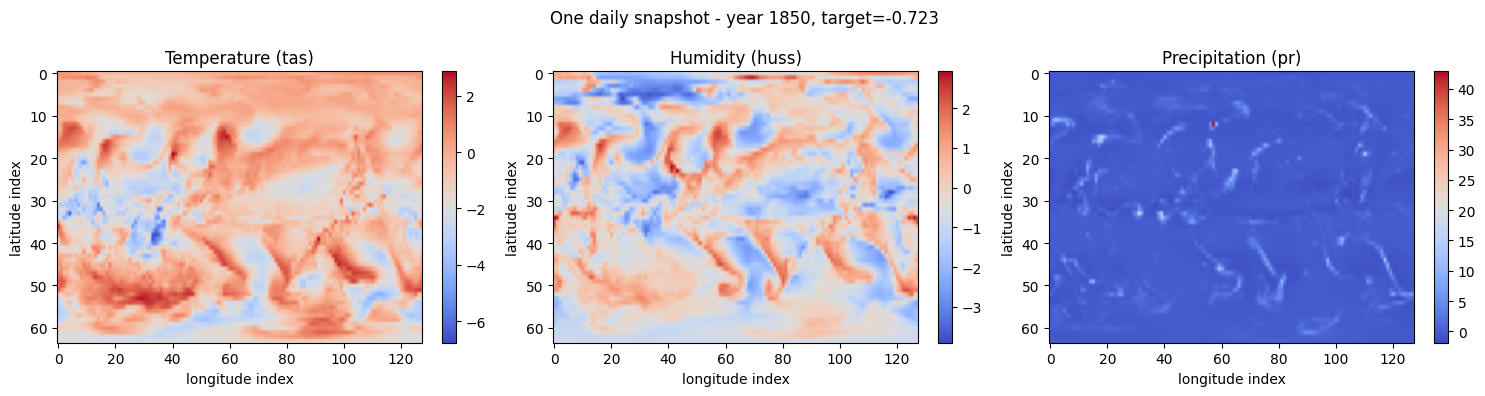

In [5]:
sample_input = np.array(sample["input"])
titles = ["Temperature (tas)", "Humidity (huss)", "Precipitation (pr)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    im = ax.imshow(sample_input[i], cmap="coolwarm", aspect="auto")
    ax.set_title(titles[i])
    ax.set_xlabel("longitude index")
    ax.set_ylabel("latitude index")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"One daily snapshot - year {sample['year']}, target={sample['target']:.3f}")
plt.tight_layout()
plt.savefig("sample_snapshot.png", dpi=150)
plt.show()


## 4. Prepare train / validation / test arrays

To keep training fast we take a **manageable random subset**
of the mini split rather than all 23.5k rows.\


In [6]:
N_TRAIN = 3000
N_VAL   = 500
N_TEST  = 500

def to_numpy(split, n):
    split = split.shuffle(seed=SEED).select(range(n))
    X = np.array(split["input"], dtype=np.float32)
    y = np.array(split["target"], dtype=np.float32)
    years = np.array(split["year"])                  # ONLY for display purposes, never fed to the model
    return X, y, years

X_train, y_train, years_train = to_numpy(dataset["train"], N_TRAIN)
X_val,   y_val,   years_val   = to_numpy(dataset["validation"], N_VAL)
X_test,  y_test,  years_test  = to_numpy(dataset["test"], N_TEST)

print(X_train.shape, y_train.shape)


(3000, 3, 64, 128) (3000,)


## 5. Baseline model - Linear Regression

**Why start here?** Before using a "fancy" deep learning model, we need a simple
"score to beat". Linear Regression treats every pixel of the map as an
independent input feature (we *flatten* the 3×64×128 grid into one long vector
of 24,576 numbers) and fits a straight-line relationship between those pixels
and the target temperature. It ignores spatial structure completely - that's
exactly the weakness the CNN will fix in the next section.

In [7]:
X_train_flat = X_train.reshape(N_TRAIN, -1)
X_val_flat   = X_val.reshape(N_VAL, -1)
X_test_flat  = X_test.reshape(N_TEST, -1)

baseline = LinearRegression()
baseline.fit(X_train_flat, y_train)

pred_val = baseline.predict(X_val_flat)
pred_test = baseline.predict(X_test_flat)

baseline_val_mse = mean_squared_error(y_val, pred_val)
baseline_test_mse = mean_squared_error(y_test, pred_test)
baseline_test_r2 = r2_score(y_test, pred_test)

print(f"Baseline (Linear Regression)")
print(f"  Validation MSE: {baseline_val_mse:.4f}")
print(f"  Test MSE:       {baseline_test_mse:.4f}")
print(f"  Test R^2:       {baseline_test_r2:.4f}")


Baseline (Linear Regression)
  Validation MSE: 0.0390
  Test MSE:       0.0255
  Test R^2:       0.9845


## 6. Main model - a small CNN

A **Convolutional Neural Network (CNN)** is the classical tool for
exactly this kind of gridded/image-like scientific data: it slides small
filters over the map to learn *local spatial patterns* (e.g. "a warm patch
next to a dry patch"), which flattening for Linear Regression threw away.[link text](https://)

In [8]:
class ClimateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)          # shape (N, 3, 64, 128)
        self.y = torch.from_numpy(y).unsqueeze(1)  # shape (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ClimateDataset(X_train, y_train)
val_ds   = ClimateDataset(X_val, y_val)
test_ds  = ClimateDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


In [9]:
class ClimateCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

model = ClimateCNN().to(device)
print(model)


ClimateCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 7. Train the CNN

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15
history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    # --- training pass ---
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_ds)

    # --- validation pass ---
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_running_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss = val_running_loss / len(val_ds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")


Epoch  1/15  train_loss=0.5034  val_loss=0.0292
Epoch  2/15  train_loss=0.0443  val_loss=0.0541
Epoch  3/15  train_loss=0.0370  val_loss=0.0400
Epoch  4/15  train_loss=0.0345  val_loss=0.0357
Epoch  5/15  train_loss=0.0334  val_loss=0.0418
Epoch  6/15  train_loss=0.0340  val_loss=0.0644
Epoch  7/15  train_loss=0.0313  val_loss=0.0379
Epoch  8/15  train_loss=0.0316  val_loss=0.0397
Epoch  9/15  train_loss=0.0308  val_loss=0.0391
Epoch 10/15  train_loss=0.0341  val_loss=0.0315
Epoch 11/15  train_loss=0.0363  val_loss=0.0682
Epoch 12/15  train_loss=0.0278  val_loss=0.0275
Epoch 13/15  train_loss=0.0315  val_loss=0.0338
Epoch 14/15  train_loss=0.0303  val_loss=0.0525
Epoch 15/15  train_loss=0.0341  val_loss=0.1058


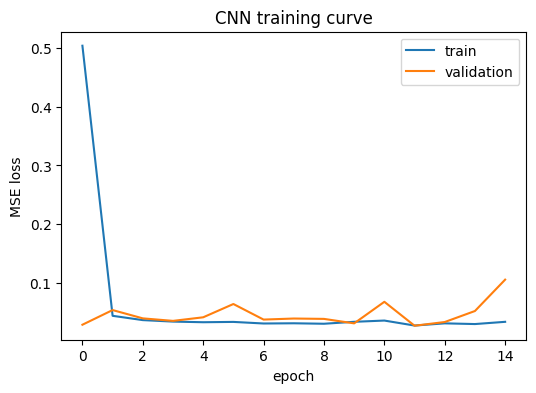

In [11]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("CNN training curve")
plt.savefig("training_curve.png", dpi=150)
plt.show()


## 8. Evaluate the CNN and compare to the baseline

CNN       Test MSE: 0.0758   Test R^2: 0.9541
Baseline  Test MSE: 0.0255   Test R^2: 0.9845


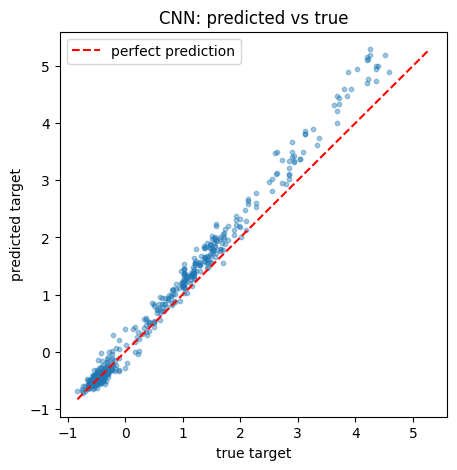

In [12]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy().flatten()
        all_preds.extend(preds)
        all_true.extend(yb.numpy().flatten())

cnn_test_mse = mean_squared_error(all_true, all_preds)
cnn_test_r2 = r2_score(all_true, all_preds)

print(f"CNN       Test MSE: {cnn_test_mse:.4f}   Test R^2: {cnn_test_r2:.4f}")
print(f"Baseline  Test MSE: {baseline_test_mse:.4f}   Test R^2: {baseline_test_r2:.4f}")

plt.figure(figsize=(5,5))
plt.scatter(all_true, all_preds, alpha=0.4, s=10)
lims = [min(all_true+all_preds), max(all_true+all_preds)]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("true target"); plt.ylabel("predicted target")
plt.title("CNN: predicted vs true"); plt.legend()
plt.savefig("pred_vs_true.png", dpi=150)
plt.show()


## 8.5. Live Demo

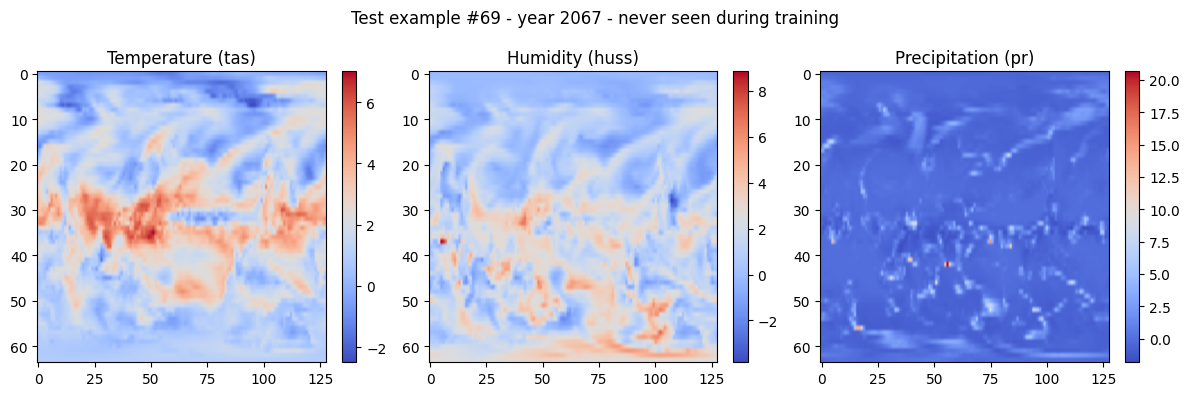

Test example index  : 69
Year this day is from: 2067  (NOT given to the model as input)
Model's prediction   : 3.2130
Actual true value    : 2.8405
Difference (error)   : 0.3726


In [13]:
DEMO_INDEX = 69

assert 0 <= DEMO_INDEX < N_TEST, f"DEMO_INDEX must be between 0 and {N_TEST - 1}"

model.eval()
x_demo, y_demo = test_ds[DEMO_INDEX]
x_demo_batch = x_demo.unsqueeze(0).to(device)
year_demo = years_test[DEMO_INDEX]

with torch.no_grad():
    pred_demo = model(x_demo_batch).item()

true_demo = y_demo.item()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Temperature (tas)", "Humidity (huss)", "Precipitation (pr)"]
for i, ax in enumerate(axes):
    im = ax.imshow(x_demo.numpy()[i], cmap="coolwarm", aspect="auto")
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"Test example #{DEMO_INDEX} - year {year_demo} - never seen during training")
plt.tight_layout()
plt.show()

print(f"Test example index  : {DEMO_INDEX}")
print(f"Year this day is from: {year_demo}  (NOT given to the model as input)")
print(f"Model's prediction   : {pred_demo:.4f}")
print(f"Actual true value    : {true_demo:.4f}")
print(f"Difference (error)   : {abs(pred_demo - true_demo):.4f}")


## 9. Explainability - where is the model looking?

We compute a **gradient saliency map**: for one test sample, we ask "if I
nudge each input pixel slightly, how much does the predicted temperature
change?" Pixels with a large gradient are the ones the CNN relies on most.

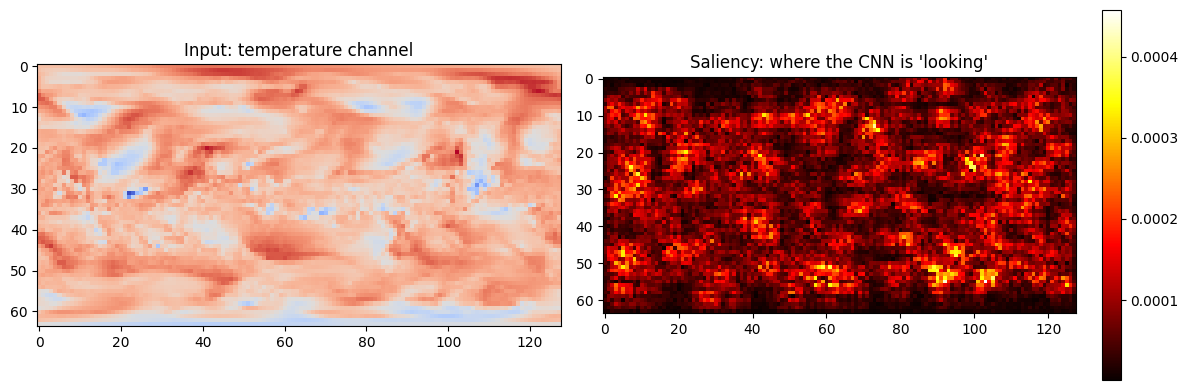

True target: -0.3535   Predicted: -0.5558


In [14]:
model.eval()
x_sample, y_sample = test_ds[0]
x_sample = x_sample.unsqueeze(0).to(device)
x_sample.requires_grad_(True)

pred = model(x_sample)
pred.backward()

saliency = x_sample.grad.abs().squeeze(0).cpu().numpy()
saliency_map = saliency.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(x_sample.detach().cpu().numpy()[0, 0], cmap="coolwarm")
axes[0].set_title("Input: temperature channel")
im = axes[1].imshow(saliency_map, cmap="hot")
axes[1].set_title("Saliency: where the CNN is 'looking'")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig("saliency_map.png", dpi=150)
plt.show()

print(f"True target: {y_sample.item():.4f}   Predicted: {pred.item():.4f}")
